In [1]:
from ultralytics import YOLO
import os
import numpy as np
import cv2
from matplotlib import pyplot as plt
import mlflow

os.environ["MLFLOW_TRACKING_URI"] = "http://127.0.0.1:5000"

c:\Users\eric.santoss\OneDrive - Sistema FIEB\Documentos\CORROSAO_FABRIC_MAINTENENCE\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import albumentations as A

In [2]:
%matplotlib inline

# Train model

In [13]:
# Define custom transforms with various augmentation techniques
custom_transforms = [
    # Flip
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.CLAHE(clip_limit=1.0, tile_grid_size=(8, 8), p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5),
]

In [20]:
# Load a model
version = "yolo26n.pt"
model = YOLO("yolo26n.pt")
# Train the model
model.train(
    data="YOLODataset/dataset.yaml",
    epochs=100,
    imgsz=640,
    batch=8,
    mosaic=0.0,
    #nms=False,
    #augmentations=custom_transforms,
    name=f"custom_yolo_model_{version.split('.')[0]}"
)

New https://pypi.org/project/ultralytics/8.4.121 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.120  Python-3.11.5 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=YOLODataset/dataset.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000019DE9B61D90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          

In [21]:
# Carregar o modelo treinado
model = YOLO(r"runs\detect\custom_yolo_model_yolo26n-3\weights\best.pt")

In [22]:
model.info()

YOLO26n summary: 260 layers, 2,504,970 parameters, 0 gradients, 5.9 GFLOPs


(260, 2504970, 0, 5.8964992)

In [23]:
# Avaliar especificamente no conjunto de TESTE
metrics = model.val(data="YOLODataset/dataset.yaml", split='test')

Ultralytics 8.4.120  Python-3.11.5 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access  (ping: 0.30.3 ms, read: 718.0373.8 MB/s, size: 815.8 KB)
val: Scanning C:\Users\eric.santoss\OneDrive - Sistema FIEB\Documentos\CORROSAO_FABRIC_MAINTENENCE\YOLODataset\labels\test.cache... 15 images, 15 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 25.1s/it 50.2s<2:46
                   all         30        109      0.286      0.322      0.228     0.0866
      corrosion_severe         11         21      0.186      0.238     0.0941     0.0329
    corrosion_moderate         12         33      0.197      0.273      0.183     0.0901
        corrosion_mild         11         55      0.474      0.455      0.407      0.137
Speed: 10.5ms preprocess, 8.7ms infer

In [24]:
print(metrics.confusion_matrix.matrix)

[[          6           0           0          20]
 [          3           7           3          28]
 [          0           2          20          23]
 [         12          24          32           0]]


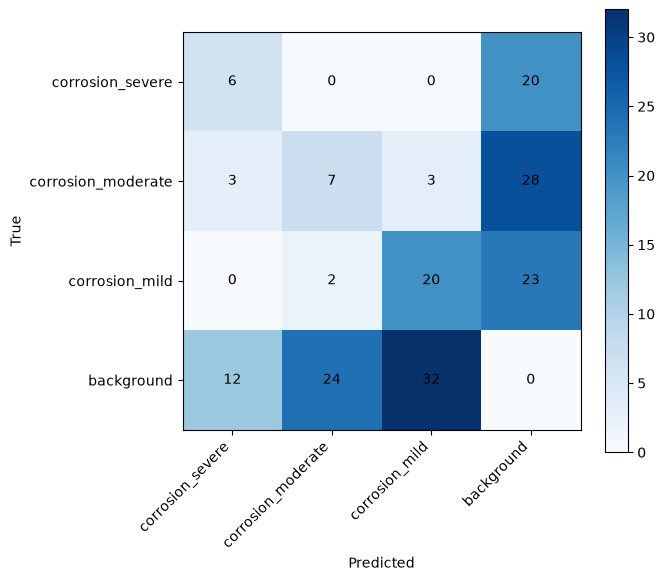

In [25]:
cm = metrics.confusion_matrix.matrix

labels = [
    "corrosion_severe",
    "corrosion_moderate",
    "corrosion_mild",
    "background"
]

fig, ax = plt.subplots(figsize=(7,6))

im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i,
            int(cm[i, j]),
            ha="center",
            va="center",
            color="black"
        )

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [ ]:
# # Iniciar log no MLflow
# with mlflow.start_run(run_name="YOLO26n on test - RGB Original"):
#     mlflow.log_param("epochs", 100)
#     mlflow.log_metric("mAP50", metrics.box.map50)
#     mlflow.log_metric("mAP50_95", metrics.box.map)
#     mlflow.log_metric("precision", metrics.box.mp)
#     mlflow.log_metric("recall", metrics.box.mr)
#     mlflow.log_metric("f1_score", metrics.box.f1[0])

In [26]:
import glob
import imageio

test_dir = r'YOLODataset\images\test'
pred_dir = os.path.join(test_dir, "predicted_frames_default")
os.makedirs(pred_dir, exist_ok=True)

image_paths = sorted(glob.glob(os.path.join(test_dir, "*.png")))

frames = []
target_shape = None

for img_path in image_paths:
    try:
        results = model.predict(
            source=img_path, imgsz=640, conf=0.3, max_det=100, verbose=False)
    except Exception as e:
        print(f'Predict failed for {os.path.basename(img_path)}: {e}')
        continue

    annotated = results[0].plot()
    if annotated is None:
        continue

    # Normalize channels to RGB uint8
    if annotated.ndim == 2:
        annotated = cv2.cvtColor(annotated, cv2.COLOR_GRAY2RGB)
    elif annotated.ndim == 3:
        ch = annotated.shape[2]
        if ch == 4:
            annotated = cv2.cvtColor(annotated, cv2.COLOR_BGRA2RGB)
        elif ch == 3:
            annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        else:
            continue
    else:
        continue

    annotated = annotated.astype('uint8')

    # Ensure consistent shape for all frames (resize to first frame shape)
    if target_shape is None:
        target_shape = annotated.shape
    if annotated.shape != target_shape:
        annotated = cv2.resize(
            annotated, (target_shape[1], target_shape[0]), interpolation=cv2.INTER_AREA)

    # Save annotated frame to folder
    base = os.path.splitext(os.path.basename(img_path))[0]
    save_path = os.path.join(pred_dir, f"{base}_pred.png")
    imageio.imwrite(save_path, annotated)
    frames.append(annotated)
    print(
        f'Gerado e salvo frame para: {os.path.basename(img_path)} -> {save_path}')

if frames:
    print(f'Todos os frames salvos em: {pred_dir}')
else:
    print('Nenhuma imagem processada para salvar.')

Gerado e salvo frame para: frame_000000_VID_20260131_095713_00_101_insv_crop3_48f182a2.png -> YOLODataset\images\test\predicted_frames_default\frame_000000_VID_20260131_095713_00_101_insv_crop3_48f182a2_pred.png
Gerado e salvo frame para: frame_000006_VID_20260131_095713_00_101_insv_crop2_b4ad591c.png -> YOLODataset\images\test\predicted_frames_default\frame_000006_VID_20260131_095713_00_101_insv_crop2_b4ad591c_pred.png
Gerado e salvo frame para: frame_000007_VID_20260131_095123_00_100_insv_crop3_14cf1775.png -> YOLODataset\images\test\predicted_frames_default\frame_000007_VID_20260131_095123_00_100_insv_crop3_14cf1775_pred.png
Gerado e salvo frame para: frame_000007_VID_20260131_095123_00_100_insv_crop4_c02c1d02.png -> YOLODataset\images\test\predicted_frames_default\frame_000007_VID_20260131_095123_00_100_insv_crop4_c02c1d02_pred.png
Gerado e salvo frame para: frame_000010_VID_20260131_095713_00_101_insv_crop2_1d73bbab.png -> YOLODataset\images\test\predicted_frames_default\frame_000

# SAHI

In [27]:
from sahi import AutoDetectionModel
from sahi.predict import get_prediction

In [29]:
detection_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=r"runs\detect\custom_yolo_model_yolo26n-3\weights\best.pt",
    confidence_threshold=0.5,
    device="cuda",  # or 'cuda:0'
)

In [ ]:
# frame = "corrosion_best_frames_croped/YOLODataset/images/test/predicted_frames/frame_000004_VID_20260131_095713_00_101_insv_crop1_d199fd41_pred.png"
# result = get_prediction(frame, detection_model)
# result.export_visuals(export_dir="corrosion_best_frames_croped/", hide_conf=False)

In [ ]:
# from PIL import Image

# # Open the predicted image
# processed_image = Image.open('corrosion_best_frames_croped/prediction_visual.png')

# # Display the predicted image
# processed_image.show()

# Previsão de lote 

In [30]:
from sahi.predict import predict

In [31]:
predict(
    model_type="ultralytics",
    model_path=r"runs\detect\custom_yolo_model_yolo26n-3\weights\best.pt",
    model_device="cuda",
    model_confidence_threshold=0.5,
    source="YOLODataset/images/test",
    slice_height=256,
    slice_width=256,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2,
)

There are 15 listed files in folder: test/


Performing inference on images:   0%|          | 0/15 [00:00<?, ?it/s]

Performing prediction on 12 slices.


Performing inference on images:   7%|▋         | 1/15 [00:00<00:07,  1.91it/s]

Prediction time is: 365.15 ms
Performing prediction on 12 slices.


...

Prediction time is: 176.03 ms
Performing prediction on 12 slices.


Performing inference on images:  93%|█████████▎| 14/15 [00:02<00:00,  5.43it/s]

Prediction time is: 151.98 ms
Performing prediction on 12 slices.
Prediction time is: 148.96 ms


Performing inference on images: 100%|██████████| 15/15 [00:03<00:00,  4.82it/s]

Performing prediction on 12 slices.
Prediction time is: 155.05 ms
Prediction results are successfully exported to runs\predict\exp
